In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('final_clean_land.csv')

In [ ]:
df.head()

,sector,area,price,open_sides,feature
0,sector 33 sohna,209,3.75,1,Premium
1,sector 93,17,2.23,1,Basic
2,sector 63,286,8.75,2,Premium
3,sector 22,42,0.90,2,Basic
4,sector 2,167,1.20,2,Basic


In [ ]:
df.shape

(2168, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2168 entries, 0 to 2167
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sector      2168 non-null   object 
 1   area        2168 non-null   int64  
 2   price       2168 non-null   float64
 3   open_sides  2168 non-null   int64  
 4   feature     2168 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 84.8+ KB


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['sector'].value_counts().shape

(108,)

<Axes: xlabel='sector'>

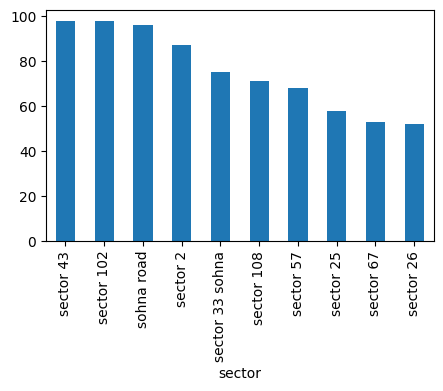

In [ ]:
plt.figure(figsize=(5,3))
df['sector'].value_counts().head(10).plot(kind = 'bar')

In [ ]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(0),
 'High (50-100)': np.int64(11),
 'Average (10-49)': np.int64(43),
 'Low (2-9)': np.int64(49),
 'Very Low (1)': np.int64(5)}

###observation
* There are a total of 108 unique sectors in the dataset.
* Frequency distribution of sectors:
  * Very High (>100): 0 sectors have more than 100 listings.
  * High (50-100): 11 sectors have between 50 to 100 listings.
  * Average (10-49): 43 sectors, fall in this range with 10 to 49 listings each.
  * Low (2-9): majority , 49 sectors have between 2 to 9 listings.
  * Very Low (1): , 5 sectors with only 1 listing.

In [ ]:
df['price'].describe()

,price
count,2064.000000
mean,4.533634
std,4.929922
min,0.010000
25%,1.700000
50%,3.400000
75%,5.800000
max,100.000000


<Axes: xlabel='price', ylabel='Count'>

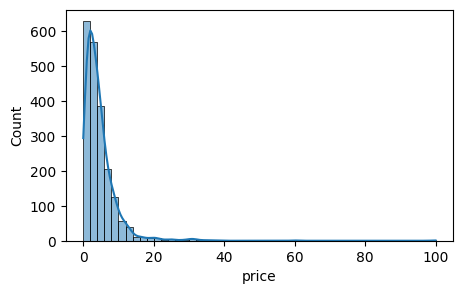

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df['price'],kde=True,bins = 50)

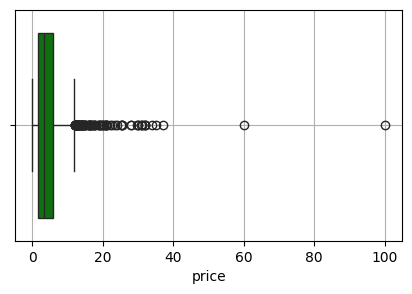

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['price'],color='green')
plt.grid()

####Descriptive Statistics:


* Mean Price: The average price is approximately 4.53 crores.
* Median Price: The median (or 50th percentile) price is 3.4 crores.
* Standard Deviation: The prices have a standard deviation of 4.92, indicating variability in the prices.
* Range: Prices range from a minimum of 0.01 crores to a maximum of 100 crores.
* IQR: The interquartile range (difference between 75th and 25th percentile) is from 1.70 crores to 5.80 crores.

####Visualizations:

* Distribution: The histogram indicates that most properties are priced in the lower range (below 15 crores), with a few properties going beyond 20 crores.
* Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 20 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

In [ ]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

6.048539996757996 81.9359263614166


* Skewness: The price distribution has a skewness of approximately 6.04, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

* Kurtosis: The kurtosis value is approximately 81.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [ ]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

,price
0.01,0.120
0.05,0.380
0.95,11.800
0.99,23.685


####Quantile Analysis:

* 1% Quantile: Only 1% of properties are priced below 0.12 crores.
* 5% Quantile: 5% of properties are priced below 0.38 crores.
* 95% Quantile: 95% of properties are priced below 11.80 crores.
* 99% Quantile: 99% of properties are priced below 23.685 crores, indicating that very few properties are priced above this value.

In [ ]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-4.449999999999999 11.95


In [ ]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(102, 5)

In [ ]:
outliers['price'].describe()

,price
count,102.000000
mean,19.288824
std,11.156694
min,12.000000
25%,13.000000
50%,16.000000
75%,21.000000
max,100.000000


#####Outliers Analysis (using IQR method):

* Based on the IQR method, there are 102 properties considered as outliers.
* These outliers have an average price of approximately 19.28 crores.
* The range for these outliers is from 12.0 crores to 100 crores.

<Axes: xlabel='price'>

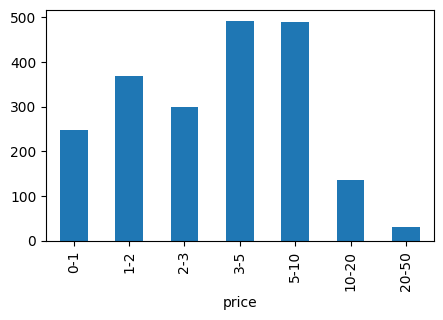

In [ ]:
# price binning
plt.figure(figsize=(5,3))
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

* The majority of properties are priced in the "3-5 crores" and "5-10 crores" ranges.
* There's a significant drop in the number of properties priced above "10 crores."

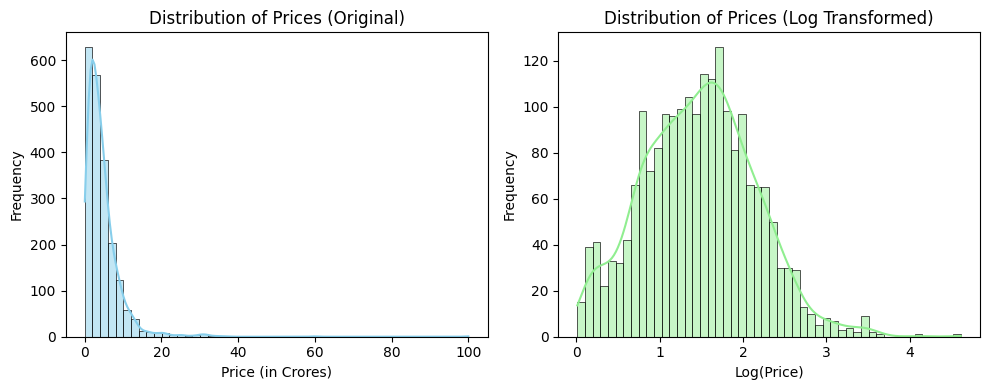

In [ ]:
plt.figure(figsize=(10, 4))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [ ]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

0.21972852114650596 0.11281559434367994


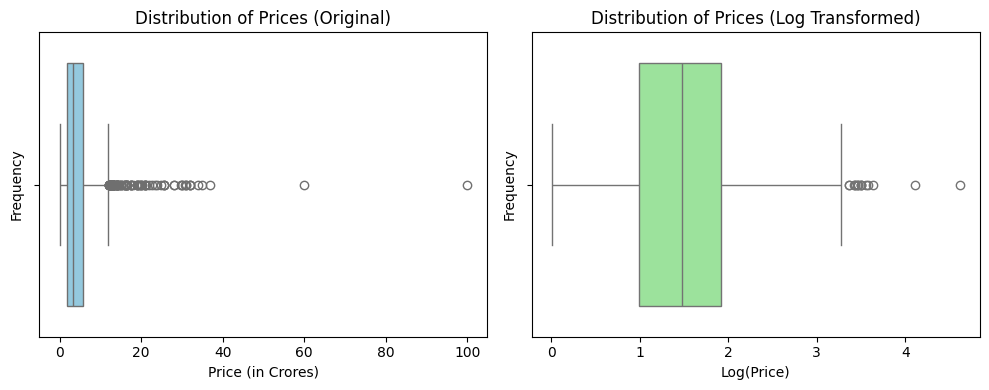

In [ ]:
plt.figure(figsize=(10, 4))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
df['area'].describe()

,area
count,2064.000000
mean,444.171512
std,2963.539822
min,0.000000
25%,121.000000
50%,188.000000
75%,286.000000
max,80937.000000


<Axes: xlabel='area', ylabel='Count'>

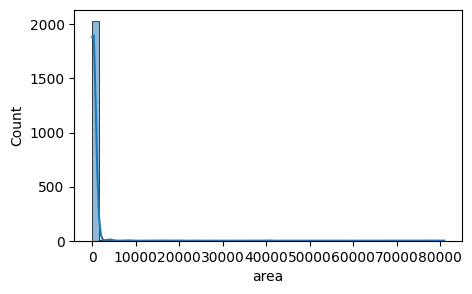

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(x=df['area'],kde=True,bins = 50)

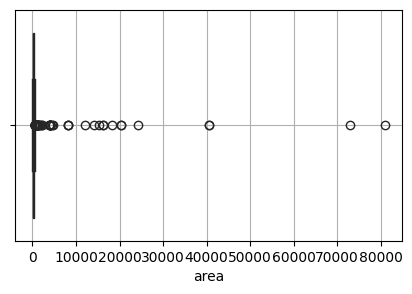

In [ ]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['area'],color='green')
plt.grid()

<Axes: xlabel='open_sides'>

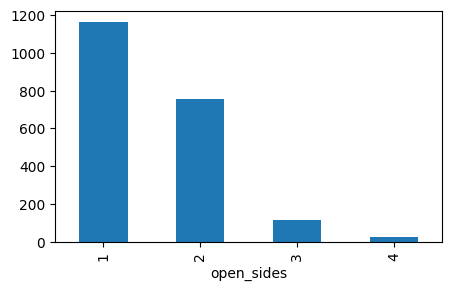

In [ ]:
plt.figure(figsize=(5,3))
df['open_sides'].value_counts().plot(kind = 'bar')

majority of properties are either one side or two side


<Axes: xlabel='feature'>

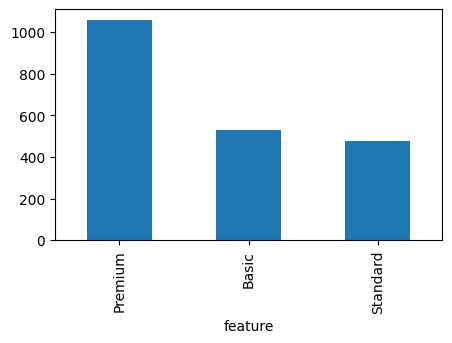

In [ ]:
plt.figure(figsize=(5,3))
df['feature'].value_counts().plot(kind = 'bar')

##### most properties are tagged as premium


## multivariate analysis

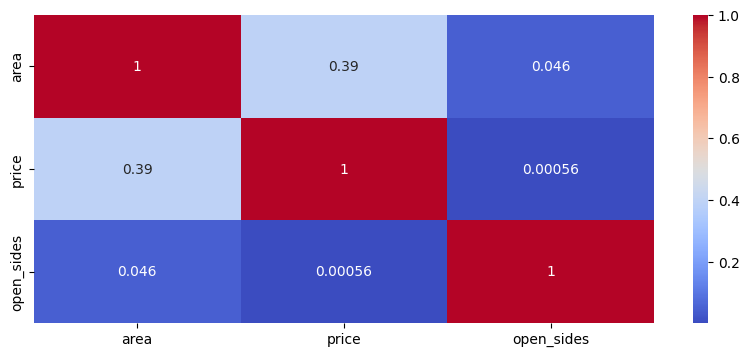

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(df[['area','price','open_sides']].corr(),
            annot=True,
            cmap='coolwarm')
plt.show()

####Observation:

Property area has a moderate positive correlation (0.39) with price, whereas open sides show negligible correlation with price.

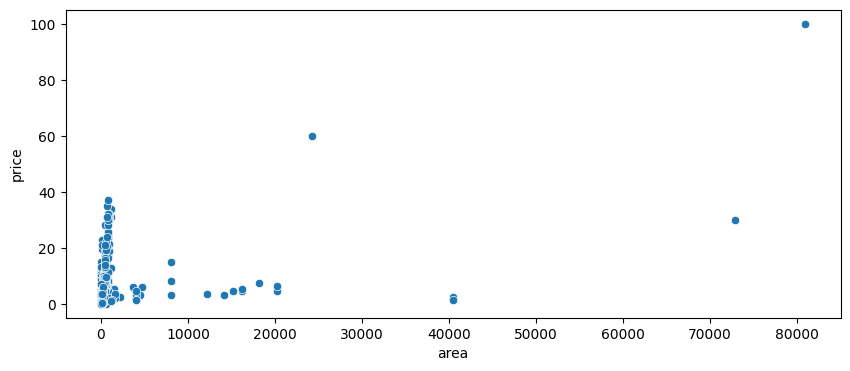

In [ ]:
plt.figure(figsize=(10, 4))
sns.scatterplot(data=df,
                x='area',
                y='price')
plt.show()

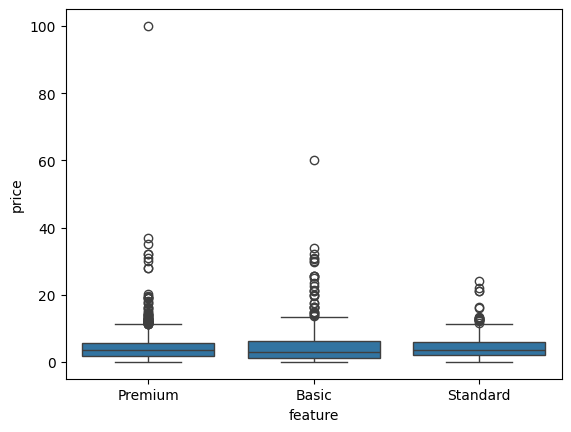

In [ ]:
sns.boxplot(data=df,
            x='feature',
            y='price')
plt.show()

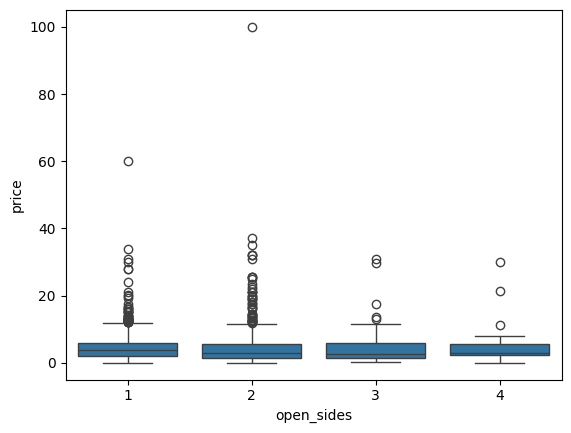

In [ ]:
sns.boxplot(data=df,
            x='open_sides',
            y='price')
plt.show()

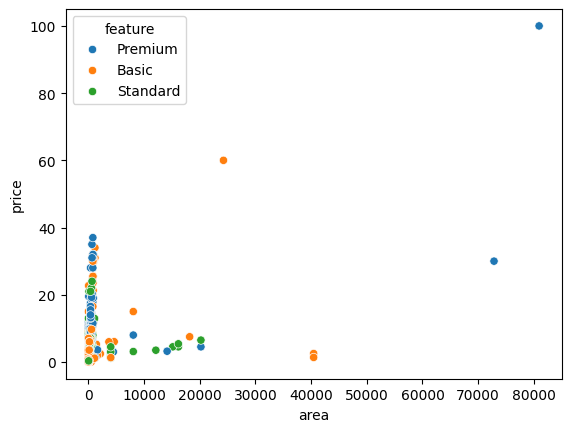

In [ ]:
sns.scatterplot(data=df,
                x='area',
                y='price',
                hue='feature')
plt.show()

In [ ]:
top_sector = df['sector'].value_counts().head(10).index

temp = df[df['sector'].isin(top_sector)]

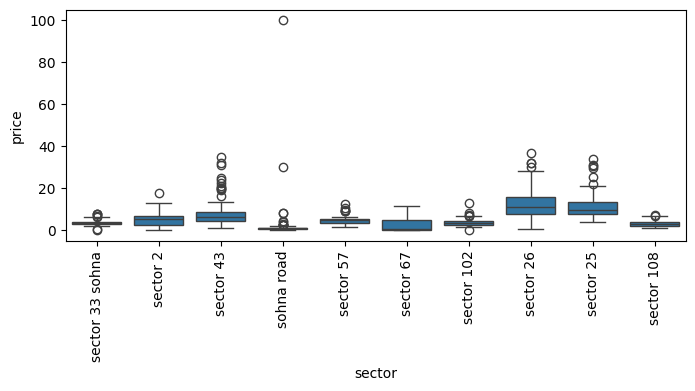

In [ ]:
plt.figure(figsize=(8,3))
sns.boxplot(data=temp,
            x='sector',
            y='price')

plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='feature', ylabel='price'>

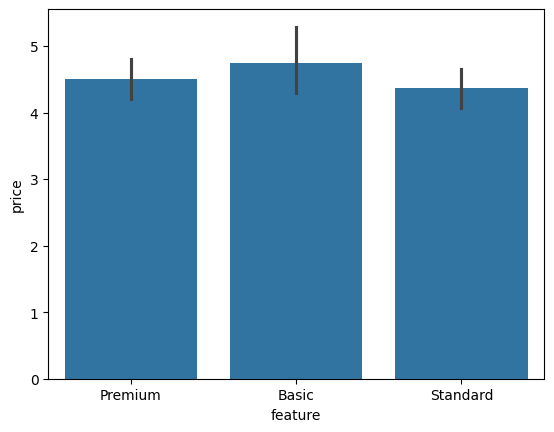

In [ ]:
sns.barplot(data=df,
            x='feature',
            y='price')